In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
files = [
    "ID-SG_Collab__EL_Transport.csv",
    "KH-SG_Collab__EL_Transport.csv",
    "MY-SG_Collab__EL_Transport.csv",
    "SG-VN_Collab__EL_Transport.csv"
]
dfs = list()
for file in files:
    data = pd.read_csv(file)
    data["cid"] = file.split("__")[0]
    data.rename(columns={"uid": "sid"}, inplace=True)
    data.columns = list(map(lambda s: s.lower(), data.columns.tolist()))
    data = data[["cid", "sid", "cost", "emissions", "el_transport"]]
    data = data.sort_values(by=["cid", "sid"])
    dfs.append(data)
df = pd.concat(dfs)
df.reset_index(drop=True, inplace=True)

In [3]:
df.loc[df.sid=="S-BAU"]

,cid,sid,cost,emissions,el_transport
10,ID-SG_Collab,S-BAU,2070.363334,0.000012,21.303210
21,KH-SG_Collab,S-BAU,240.722479,0.000010,14.287253
32,MY-SG_Collab,S-BAU,571.016375,0.000022,15.494765
43,SG-VN_Collab,S-BAU,785.371565,0.000260,14.148412


In [4]:
data = df.loc[df.sid!="S-BAU"]
data["sid"] = data.sid.apply(lambda s: int(s.split("-")[-1]))

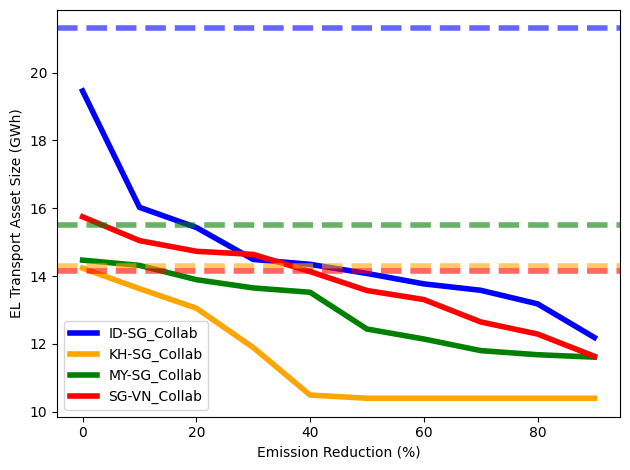

In [5]:
pal = {
    "ID-SG_Collab": "blue",
    "KH-SG_Collab": "orange",
    "MY-SG_Collab": "green",
    "SG-VN_Collab": "red"
}

fig, ax = plt.subplots()
for cid, group in data.groupby("cid"):
    x = group["sid"].values
    y = group["el_transport"].values
    ax.plot(x, y, lw=4, label=cid, color=pal[cid])
ax.set_xlabel("Emission Reduction (%)")
ax.set_ylabel("EL Transport Asset Size (GWh)")
ax.axhline(y=df.loc[(df.cid=="ID-SG_Collab")&(df.sid=="S-BAU"), "el_transport"].item(), color="blue", lw=4, ls="--", alpha=.6)
ax.axhline(y=df.loc[(df.cid=="KH-SG_Collab")&(df.sid=="S-BAU"), "el_transport"].item(), color="orange", lw=4, ls="--", alpha=.6)
ax.axhline(y=df.loc[(df.cid=="MY-SG_Collab")&(df.sid=="S-BAU"), "el_transport"].item(), color="green", lw=4, ls="--", alpha=.6)
ax.axhline(y=df.loc[(df.cid=="SG-VN_Collab")&(df.sid=="S-BAU"), "el_transport"].item(), color="red", lw=4, ls="--", alpha=.6)
ax.legend(title=None)
plt.tight_layout()
plt.show()